# Feature Engineering

Calls `src/features.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config
from src.features import compute_volatility_features

## Volatility Features

Five features per stock per week: RV at 5, 10, 21, 63 trading day lookbacks, plus RV(5d)/RV(63d) ratio.
Each value uses only daily returns strictly before the prediction week starts.

In [2]:
# Load data produced by Phase 1
log_returns = pd.read_parquet(f"{config.DATA_RAW_DIR}/log_returns.parquet")
weekly_rv   = pd.read_parquet(f"{config.DATA_RAW_DIR}/weekly_rv.parquet")

vol_features = compute_volatility_features(log_returns, weekly_rv)
print("Shape:", vol_features.shape)
print("Feature names:", vol_features.columns.get_level_values(0).unique().tolist())

Shape: (573, 250)
Feature names: ['rv_5d', 'rv_10d', 'rv_21d', 'rv_63d', 'rv_ratio']


In [3]:
# Spot-check 1: RV values must be positive (ignoring NaN warm-up rows)
for feat in ["rv_5d", "rv_10d", "rv_21d", "rv_63d"]:
    vals = vol_features[feat].values
    non_nan = vals[~np.isnan(vals)]
    assert (non_nan >= 0).all(), f"{feat} contains negative values"
    print(f"{feat}: min={non_nan.min():.4f}  mean={non_nan.mean():.4f}  max={non_nan.max():.4f}")

ratio_vals = vol_features["rv_ratio"].values
ratio_non_nan = ratio_vals[~np.isnan(ratio_vals)]
print(f"rv_ratio: min={ratio_non_nan.min():.4f}  mean={ratio_non_nan.mean():.4f}  max={ratio_non_nan.max():.4f}")

rv_5d: min=0.0102  mean=0.2389  max=5.6861
rv_10d: min=0.0275  mean=0.2523  max=4.3792
rv_21d: min=0.0607  mean=0.2619  max=3.5477
rv_63d: min=0.0806  mean=0.2721  max=2.3355
rv_ratio: min=0.0512  mean=0.8926  max=3.5778


In [4]:
# Spot-check 2: RV_5d should be more variable than RV_63d (short-term vol is noisier)
std_5d  = vol_features["rv_5d"].stack().std()
std_63d = vol_features["rv_63d"].stack().std()
print(f"Cross-stock/time std — rv_5d: {std_5d:.4f}   rv_63d: {std_63d:.4f}")
assert std_5d > std_63d, "Expected rv_5d to be more variable than rv_63d"

# Spot-check 3: rv_ratio should spike during the March 2020 COVID week
# The week of 2020-03-16 should have an above-average ratio (short-term vol >> long-term baseline)
covid_week = pd.Timestamp("2020-03-16")
if covid_week in vol_features.index:
    median_ratio  = vol_features["rv_ratio"].median(axis=1)
    overall_median = median_ratio.median()
    covid_ratio    = median_ratio.loc[covid_week]
    print(f"Median rv_ratio — overall: {overall_median:.3f}   2020-03-16: {covid_ratio:.3f}")
    assert covid_ratio > overall_median * 2, (
        f"Expected COVID ratio >> overall median; got {covid_ratio:.3f} vs {overall_median:.3f}"
    )
else:
    print("2020-03-16 not in index (may be a holiday-shortened week that was dropped)")

Cross-stock/time std — rv_5d: 0.1849   rv_63d: 0.1360
Median rv_ratio — overall: 0.797   2020-03-16: 2.949


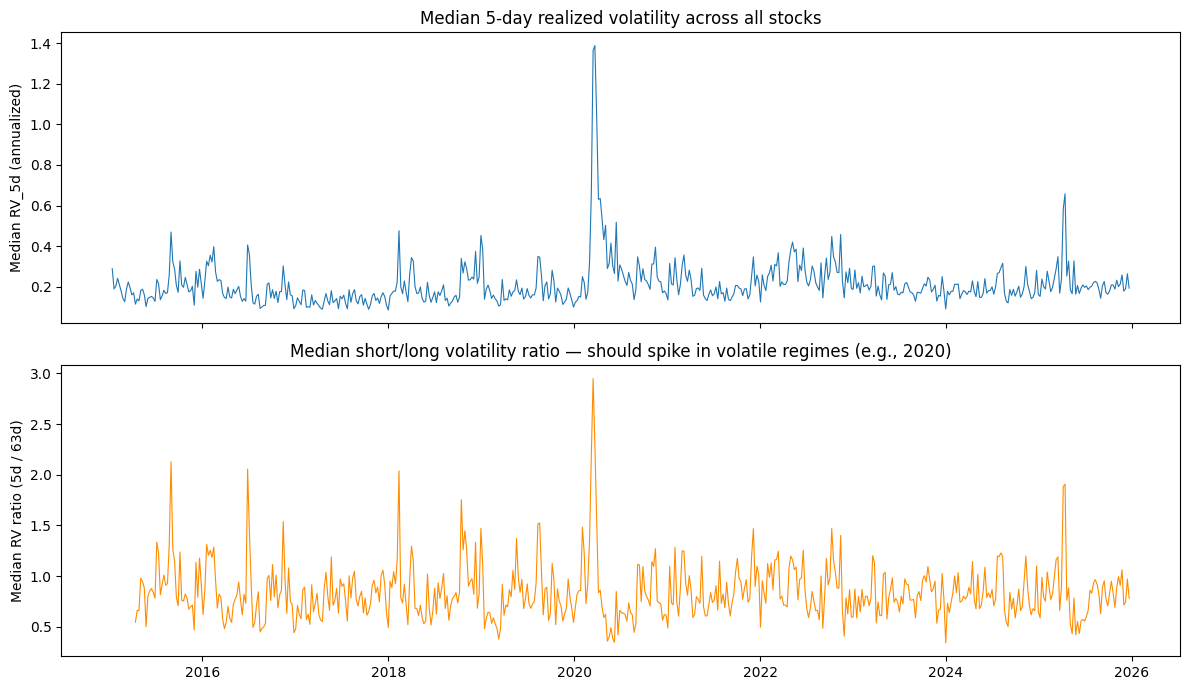

In [5]:
# Plot: median rv_5d and rv_ratio over time to visually confirm volatility clustering and COVID spike
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

median_rv5   = vol_features["rv_5d"].median(axis=1)
median_ratio = vol_features["rv_ratio"].median(axis=1)

axes[0].plot(median_rv5.index, median_rv5.values, linewidth=0.8)
axes[0].set_ylabel("Median RV_5d (annualized)")
axes[0].set_title("Median 5-day realized volatility across all stocks")

axes[1].plot(median_ratio.index, median_ratio.values, linewidth=0.8, color="darkorange")
axes[1].set_ylabel("Median RV ratio (5d / 63d)")
axes[1].set_title("Median short/long volatility ratio — should spike in volatile regimes (e.g., 2020)")

plt.tight_layout()
plt.show()

## Return and Volume Features

Five features: 5-day and 20-day cumulative log return (momentum), 5-day and 20-day mean volume, and the volume ratio.
All windows end at the Friday before the prediction week starts.

In [6]:
from src.features import compute_return_volume_features

volume = pd.read_parquet(f"{config.DATA_RAW_DIR}/volume.parquet")
print("Volume shape:", volume.shape)

Volume shape: (2765, 50)


In [7]:
ret_vol_features = compute_return_volume_features(log_returns, volume, weekly_rv)
print("Shape:", ret_vol_features.shape)
print("Feature names:", ret_vol_features.columns.get_level_values(0).unique().tolist())

Shape: (573, 250)
Feature names: ['momentum_5d', 'momentum_20d', 'mean_vol_5d', 'mean_vol_20d', 'volume_ratio']


In [8]:
# Lagging verification: pick a specific week T and confirm momentum_5d equals
# the sum of log_returns over the 5 trading days ending before Monday_T.
check_week = weekly_rv.index[70]  # arbitrary week well past warm-up
check_ticker = weekly_rv.columns[0]

# Find the last 5 trading days before check_week
prior_days = log_returns.index[log_returns.index < check_week]
expected_momentum = log_returns.loc[prior_days[-5:], check_ticker].sum()
actual_momentum   = ret_vol_features.loc[check_week, ("momentum_5d", check_ticker)]

print(f"Check week : {check_week.date()}")
print(f"5 days used: {prior_days[-5].date()} → {prior_days[-1].date()}")
print(f"Expected momentum_5d : {expected_momentum:.6f}")
print(f"Actual momentum_5d   : {actual_momentum:.6f}")
assert abs(expected_momentum - actual_momentum) < 1e-10, "Lagging alignment mismatch"
print("Lagging check passed.")

Check week : 2016-05-09
5 days used: 2016-05-02 → 2016-05-06
Expected momentum_5d : 0.012386
Actual momentum_5d   : 0.012386
Lagging check passed.


In [9]:
# Spot-check volume features: mean volumes must be positive, ratio must be positive
for feat in ["mean_vol_5d", "mean_vol_20d", "volume_ratio"]:
    vals = ret_vol_features[feat].values
    non_nan = vals[~np.isnan(vals)]
    assert (non_nan > 0).all(), f"{feat} contains non-positive values"
    print(f"{feat}: min={non_nan.min():.0f}  median={np.median(non_nan):.0f}  max={non_nan.max():.0f}")

# Volume ratio should be centered near 1 (5d mean / 20d mean ≈ 1 in calm periods)
ratio_vals = ret_vol_features["volume_ratio"].stack().dropna()
print(f"\nvolume_ratio — mean: {ratio_vals.mean():.3f}  std: {ratio_vals.std():.3f}")
assert 0.5 < ratio_vals.mean() < 2.0, "Volume ratio mean far from 1 — check alignment"

mean_vol_5d: min=71740  median=2691250  max=400290400
mean_vol_20d: min=94165  median=2769818  max=310117960
volume_ratio: min=0  median=1  max=3

volume_ratio — mean: 1.003  std: 0.243
